# FinTech Product Preferences Based on Demographic Analysis

This project analyzes how demographic factors influence FinTech adoption using survey responses collected through Google Forms.

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.cluster import KMeans
from sklearn.tree import DecisionTreeClassifier, plot_tree
import numpy as np
from scipy.stats import chi2_contingency
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import os

# Loading data
df = pd.read_csv("Fintech_Survey_Responses.csv")

# Clean column names
df.columns = df.columns.str.strip()

# Data Cleaning & Mapping 
freq_map = {"Daily": 30, "Weekly": 8, "Monthly": 1, "Rarely": 0}
df["Usage_Frequency_Num"] = df["How frequently do you make digital payments?"].map(freq_map)

val_map = {"Below 5k": 5000, "5k-20k": 15000, "20k-50k": 35000, "50k+": 60000}
df["Monthly_Transaction_Value_Num"] = df["What is your average monthly spend through digital payments?"].map(val_map)

print(df.head())

sns.set(style="whitegrid")


rename_map = {
    "What is your age group?": "Age",
    "Education level": "Education",
    "Employment Status": "Employment",
    "Monthly income (in ₹)": "Income",
    "Which payment apps do you use most frequently?": "PaymentApps",
    "How frequently do you make digital payments?": "PaymentFreq",
    "What is your average monthly spend through digital payments?": "PaymentSpend",
    "What is the primary reason you use payment apps?": "PaymentReason",
    "On a scale of 1–5, how satisfied are you with digital payment apps?": "PaymentSatisfaction",
    "Have you ever faced issues while using payment apps?": "PaymentIssues",
    "If yes, please describe the issues.": "PaymentIssuesDesc",
    "Have you ever used a digital loan app?": "LoanUsed",
    "If yes, which apps have you used?": "LoanAppsUsed",
    "What type of loan did you avail?": "LoanType",
    "What was the loan amount range?": "LoanAmountRange",
    "What was your reason for taking the loan?": "LoanReason",
    "How would you rate your experience with loan apps?": "LoanExperienceRating",
    "Biggest concern with loan apps?": "LoanConcern",
    "Do you invest using fintech apps?": "InvestUsingFintech",
    "If yes, which apps do you use?": "InvestAppsUsed",
    "What kind of investment products do you use?": "InvestProducts",
    "What is your average monthly investment?": "AvgMonthlyInvestment",
    "What is your primary motivation for investing?": "InvestMotivation",
    "On a scale of 1–5, how satisfied are you with your investment app(s)?": "InvestSatisfaction",
    "What is your biggest concern while investing via apps?": "InvestConcern",
    "Full Name": "FullName",
    "Timestamp": "Timestamp",
    "Email Address": "Email",
    "Column 30": "Column30"
}
df.rename(columns=rename_map, inplace=True)

text_cols = df.select_dtypes(include=['object']).columns.tolist()
df[text_cols] = df[text_cols].fillna("Not Provided")

# Creating useful derived columns
df['PaymentApps_list'] = df['PaymentApps'].astype(str).str.split(',').apply(lambda lst: [s.strip().title() for s in lst if str(s).strip() != ''])
df['PrimaryPaymentApp'] = df['PaymentApps_list'].apply(lambda l: l[0] if len(l)>0 else "Not Provided")
payment_exploded = df.explode('PaymentApps_list')
payment_exploded['PaymentApps_list'] = payment_exploded['PaymentApps_list'].fillna("Not Provided")

df['InvestAppsUsed_list'] = df['InvestAppsUsed'].astype(str).str.split(',').apply(lambda lst: [s.strip().title() for s in lst if str(s).strip() != ''])
df['PrimaryInvestApp'] = df['InvestAppsUsed_list'].apply(lambda l: l[0] if len(l)>0 else "Not Provided")
invest_exploded = df.explode('InvestAppsUsed_list')
invest_exploded['InvestAppsUsed_list'] = invest_exploded['InvestAppsUsed_list'].fillna("Not Provided")

# Basic summaries
print("Dataset shape:", df.shape)
print("\nAge counts:\n", df['Age'].value_counts())
print("\nGender counts:\n", df['Gender'].value_counts())
print("\nIncome counts:\n", df['Income'].value_counts())
print("\nInvestUsingFintech counts:\n", df['InvestUsingFintech'].value_counts())
print("\nPrimaryPaymentApp (top 15):\n", payment_exploded['PaymentApps_list'].value_counts().head(15))

            Timestamp                  Full Name What is your age group?  \
0  8/26/2025 14:31:32               Gaurav Yadav                   18–24   
1  8/26/2025 14:32:57  Chitraksh mangesh alekar                    18–24   
2  8/26/2025 14:34:43       satvik harish shetty                   18–24   
3  8/26/2025 14:35:08               Tejas  pawar                   18–24   
4  8/26/2025 14:47:50      Satvik harish shetty                    18–24   

  Gender Education level Employment Status Monthly income (in ₹)    Location  \
0   Male   Undergraduate           Student     Less than ₹10,000       Urban   
1   Male   Undergraduate           Student     Less than ₹10,000  Semi-urban   
2   Male   Undergraduate           Student     Less than ₹10,000       Urban   
3   Male   Undergraduate           Student     Less than ₹10,000       Urban   
4   Male   Undergraduate           Student     Less than ₹10,000       Urban   

  Which payment apps do you use most frequently?  \
0         

# Exploratory Data Analysis (EDA)

This section explores user behaviour through various visualizations including payment preferences, investment choices, and demographic trends.

C:\Users\DHRUV\AppData\Local\Temp\ipykernel_17492\1307991018.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=payment_counts.head(12).values, y=payment_counts.head(12).index, palette="viridis")


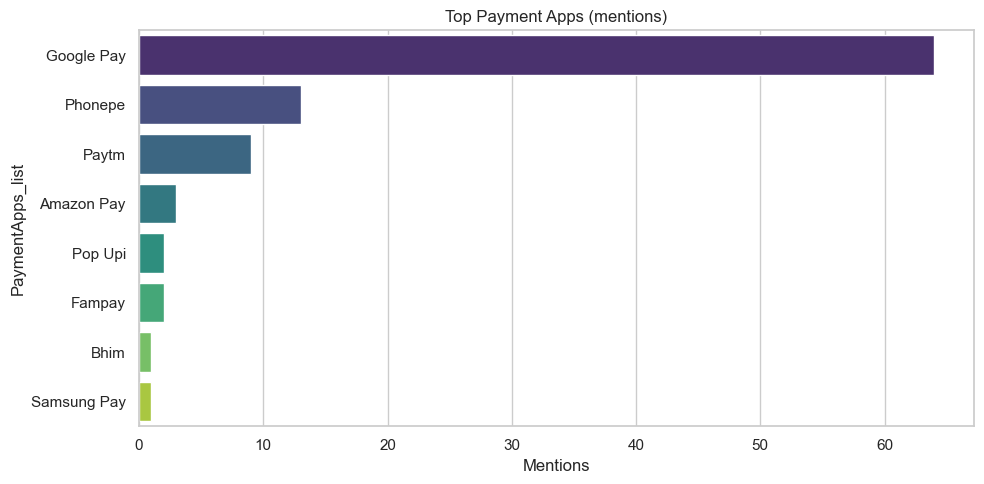

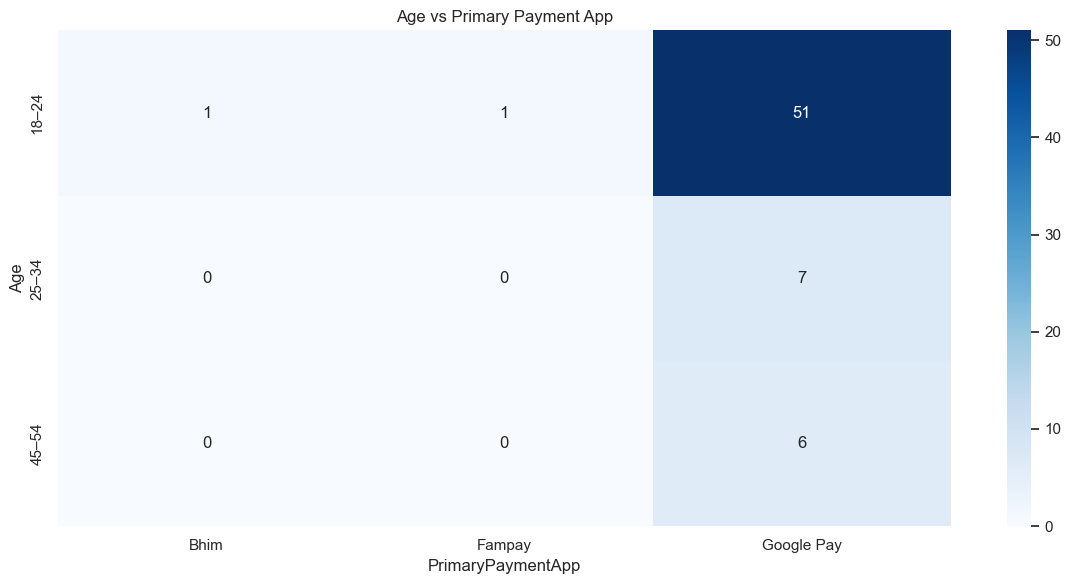

C:\Users\DHRUV\AppData\Local\Temp\ipykernel_17492\1307991018.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='PaymentFreq', order=df['PaymentFreq'].value_counts().index, palette="Set2")


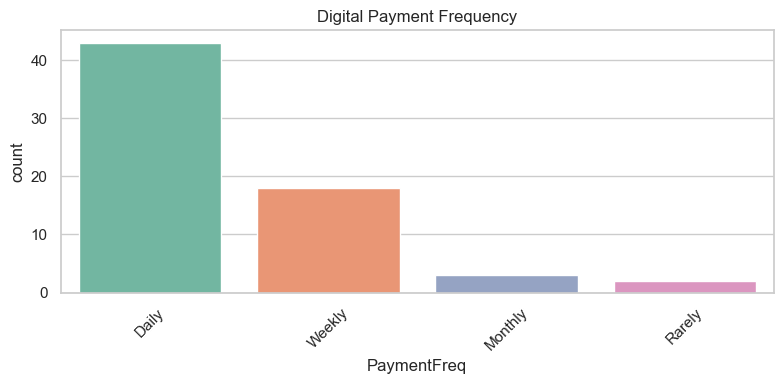

C:\Users\DHRUV\AppData\Local\Temp\ipykernel_17492\1307991018.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=invest_product_counts.head(12).values, y=invest_product_counts.head(12).index, palette="magma")


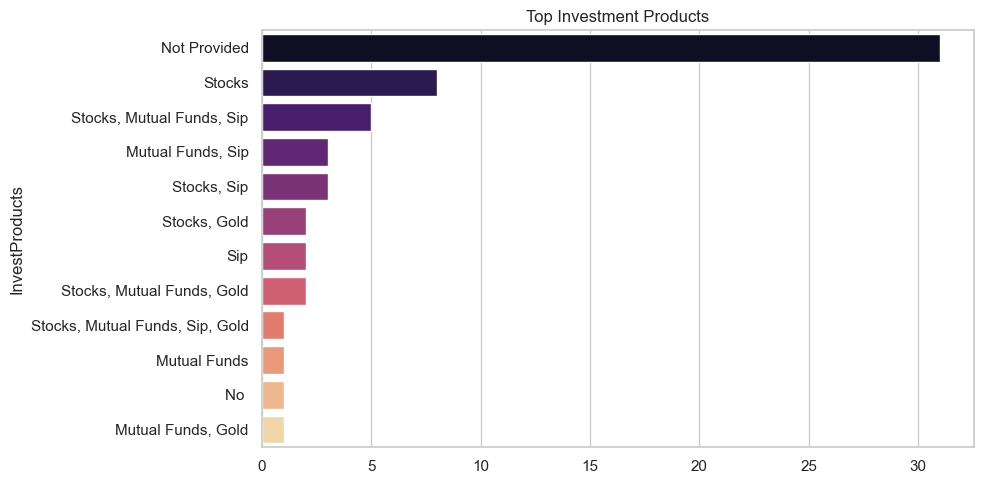

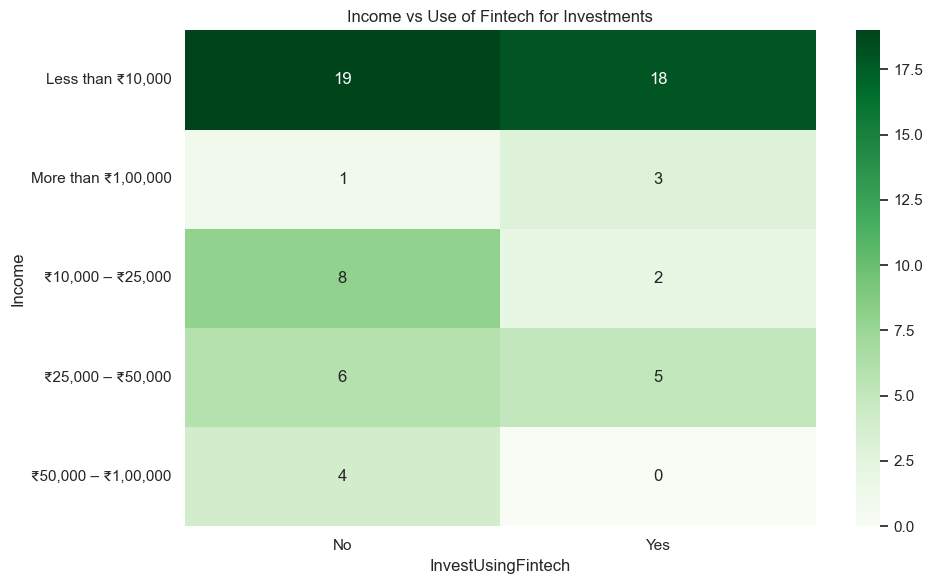

In [3]:

# Top payment apps
payment_counts = payment_exploded['PaymentApps_list'].value_counts()
plt.figure(figsize=(10,5))
sns.barplot(x=payment_counts.head(12).values, y=payment_counts.head(12).index, palette="viridis")
plt.title("Top Payment Apps (mentions)")
plt.xlabel("Mentions")
plt.tight_layout()
plt.show()

# Age vs Primary Payment App heatmap
ct_age_payment = pd.crosstab(df['Age'], df['PrimaryPaymentApp'])
plt.figure(figsize=(12,6))
sns.heatmap(ct_age_payment, annot=True, fmt="d", cmap="Blues")
plt.title("Age vs Primary Payment App")
plt.tight_layout()
plt.show()

# Payment frequency
plt.figure(figsize=(8,4))
sns.countplot(data=df, x='PaymentFreq', order=df['PaymentFreq'].value_counts().index, palette="Set2")
plt.xticks(rotation=45)
plt.title("Digital Payment Frequency")
plt.tight_layout()
plt.show()

# Top investment products
invest_product_counts = df['InvestProducts'].astype(str).str.title().value_counts()
plt.figure(figsize=(10,5))
sns.barplot(x=invest_product_counts.head(12).values, y=invest_product_counts.head(12).index, palette="magma")
plt.title("Top Investment Products")
plt.tight_layout()
plt.show()

# Income vs InvestUsingFintech
ct_income_invest = pd.crosstab(df['Income'], df['InvestUsingFintech'])
plt.figure(figsize=(10,6))
sns.heatmap(ct_income_invest, annot=True, fmt="d", cmap="Greens")
plt.title("Income vs Use of Fintech for Investments")
plt.tight_layout()
plt.show()

# Statistical Analysis & Machine Learning

Chi-Square testing was performed to identify statistically significant relationships between demographic variables and FinTech preferences.

A Decision Tree Classifier was also used to analyze investment behaviour.

Chi-square for Age vs PrimaryPaymentApp: chi2=0.506, p-value=0.972924, dof=4
Chi-square for Income vs InvestUsingFintech: chi2=7.372, p-value=0.117487, dof=4
Decision Tree accuracy: 0.47058823529411764
              precision    recall  f1-score   support

           0       0.56      0.50      0.53        10
           1       0.38      0.43      0.40         7

    accuracy                           0.47        17
   macro avg       0.47      0.46      0.46        17
weighted avg       0.48      0.47      0.47        17



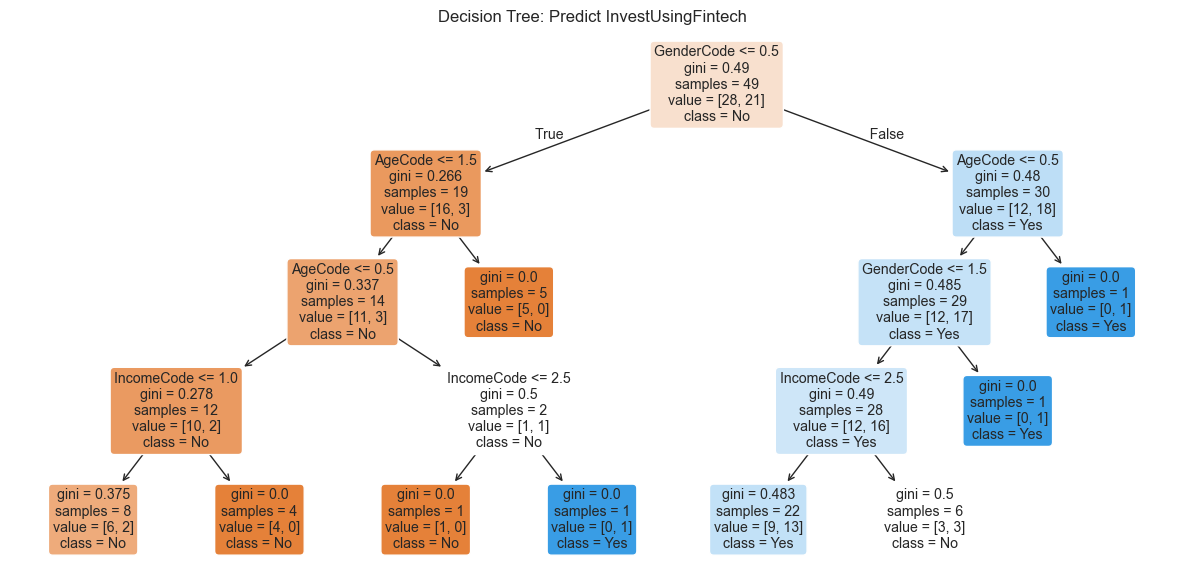

Cleaned CSV saved to: Cleaned_Fintech_Survey.csv


In [4]:
# Chi-square tests
def safe_chi2(table, name):
    from scipy.stats import chi2_contingency
    if table.size == 0 or table.shape[0] < 2 or table.shape[1] < 2:
        print(f"Chi2 test skipped for {name} (insufficient categories).")
        return None
    chi2, p, dof, expected = chi2_contingency(table)
    print(f"Chi-square for {name}: chi2={chi2:.3f}, p-value={p:.6f}, dof={dof}")
    return (chi2, p, dof)

safe_chi2(ct_age_payment, "Age vs PrimaryPaymentApp")
safe_chi2(ct_income_invest, "Income vs InvestUsingFintech")

# Simple ML: Decision Tree to predict InvestUsingFintech (Yes/No)
# Encode Age/Gender/Income into numeric codes
df['AgeCode'] = pd.Categorical(df['Age']).codes
df['GenderCode'] = pd.Categorical(df['Gender']).codes
df['IncomeCode'] = pd.Categorical(df['Income']).codes
df['InvestBinary'] = df['InvestUsingFintech'].str.strip().str.lower().map({'yes':1, 'no':0}).fillna(0).astype(int)

if df['InvestBinary'].nunique() > 1:
    X = df[['AgeCode','GenderCode','IncomeCode']]
    y = df['InvestBinary']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
    tree = DecisionTreeClassifier(max_depth=4, random_state=42)
    tree.fit(X_train, y_train)
    y_pred = tree.predict(X_test)
    print("Decision Tree accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    plt.figure(figsize=(12,6))
    plot_tree(tree, feature_names=X.columns, class_names=['No','Yes'], filled=True, rounded=True)
    plt.title("Decision Tree: Predict InvestUsingFintech")
    plt.tight_layout()
    plt.show()
else:
    print("Not enough variation to build InvestUsingFintech model.")

# Save cleaned dataset locally
df.to_csv("Cleaned_Fintech_Survey.csv", index=False)
print("Cleaned CSV saved to: Cleaned_Fintech_Survey.csv")



# Interactive Visualization

An interactive Plotly Sunburst chart was created to visualize investment product preferences across different income groups.

In [1]:
import pandas as pd
import plotly.express as px

# Loading CSV
file_path = "Fintech_Survey_Responses.csv"
df = pd.read_csv(file_path)

# Clean column names
df.columns = df.columns.str.strip()

# Select exact columns
income_col = "Monthly income (in ₹)"
invest_col = "Do you invest using fintech apps?"
product_col = "What kind of investment products do you use?"

# Handle multiple selections in products
df["PrimaryProduct"] = df[product_col].astype(str).str.split(",").str[0].str.strip()

# Build Sunburst chart
fig = px.sunburst(
    df,
    path=[income_col, invest_col, "PrimaryProduct"],
    color=income_col,
    color_discrete_sequence=px.colors.qualitative.Set3,
    title="Income → Fintech Investment Adoption → Investment Products"
)

fig.update_traces(textinfo="label+percent entry")

# Show chart
fig.show()





# Conclusion

The project demonstrates how demographic characteristics influence FinTech adoption using exploratory data analysis, statistical testing, machine learning, and interactive visualizations.